In [1]:
"https://drive.google.com/file/d/14nkiHT888rOPtX9WuS_i74EqunH0CCFW/view?usp=sharing"
file_id="14nkiHT888rOPtX9WuS_i74EqunH0CCFW"
url=f"https://drive.google.com/uc?id={file_id}"
import pandas as pd
df=pd.read_csv(url)
df


,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727
...,...,...
163,1975-08,858
164,1975-09,817
165,1975-10,827
166,1975-11,797


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")


In [3]:
print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())


First 5 Rows:
      Date  Production
0  1962-01         589
1  1962-02         561
2  1962-03         640
3  1962-04         656
4  1962-05         727

Dataset Shape:
(168, 2)

Column Names:
Index(['Date', 'Production'], dtype='object')

Missing Values:
Date          0
Production    0
dtype: int64


In [4]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Set Date as index
df.set_index('Date', inplace=True)

print("\nUpdated Dataset:")
print(df.head())


Updated Dataset:
            Production
Date                  
1962-01-01         589
1962-02-01         561
1962-03-01         640
1962-04-01         656
1962-05-01         727


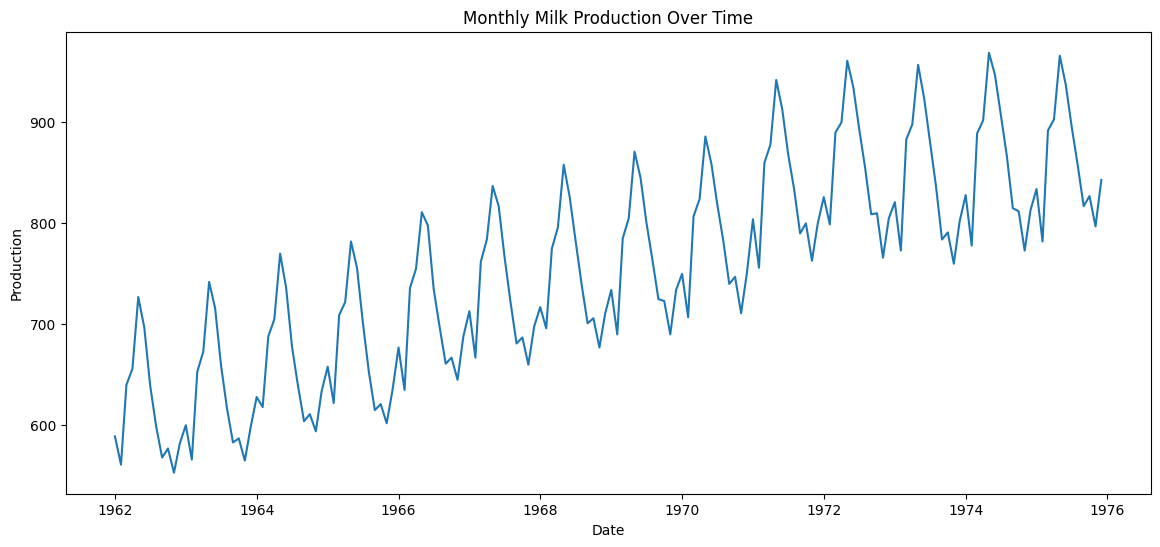

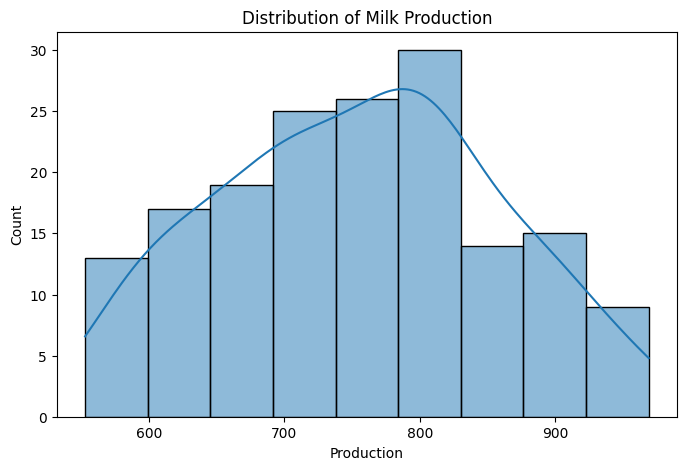

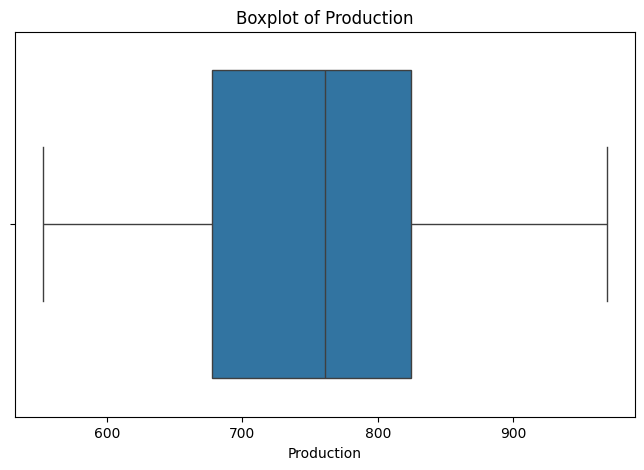

In [5]:
# Step 4: Exploratory Data Analysis (EDA)

plt.figure(figsize=(14,6))
plt.plot(df['Production'])
plt.title("Monthly Milk Production Over Time")
plt.xlabel("Date")
plt.ylabel("Production")
plt.show()


# Distribution Plot
plt.figure(figsize=(8,5))
sns.histplot(df['Production'], kde=True)
plt.title("Distribution of Milk Production")
plt.show()


# Boxplot for Outlier Detection
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Production'])
plt.title("Boxplot of Production")
plt.show()


In [6]:
# Step 5: Normalize Data

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[['Production']])

print("\nScaled Data Sample:")
print(scaled_data[:5])




Scaled Data Sample:
[[0.08653846]
 [0.01923077]
 [0.20913462]
 [0.24759615]
 [0.41826923]]


In [7]:
# Step 6: Create Sequences

def create_sequences(data, time_step=12):
    X = []
    y = []

    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])

    return np.array(X), np.array(y)


time_step = 12

X, y = create_sequences(scaled_data, time_step)

print("\nX Shape Before Reshape:", X.shape)
print("y Shape:", y.shape)


# Reshape for RNN/LSTM/GRU
X = X.reshape(X.shape[0], X.shape[1], 1)

print("\nX Shape After Reshape:", X.shape)




X Shape Before Reshape: (156, 12)
y Shape: (156,)

X Shape After Reshape: (156, 12, 1)


In [8]:
# Step 7: Train Test Split
train_size = int(len(X) * 0.80)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)




Training Data Shape: (124, 12, 1)
Testing Data Shape: (32, 12, 1)


In [9]:
# Step 8: Evaluation Function

def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"\n{model_name} Performance")
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("MAPE:", mape)

    return rmse, mae, mape

In [17]:
# Hyperparameter Tuning for RNN

for units in [32, 50, 64]:
    temp_model = Sequential()
    temp_model.add(SimpleRNN(units, activation='relu', input_shape=(time_step, 1)))
    temp_model.add(Dense(1))

    temp_model.compile(
        optimizer='adam',
        loss='mean_squared_error'
    )

    history = temp_model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=16,
        verbose=0
    )

    print(f"Units: {units}, Final Loss: {history.history['loss'][-1]}")

Units: 32, Final Loss: 0.0006724746781401336
Units: 50, Final Loss: 0.0015076056588441133
Units: 64, Final Loss: 0.0005091896164231002


In [22]:
# Step 9: Build Simple RNN Model

rnn_model = Sequential([
    SimpleRNN(64, activation='tanh', input_shape=(time_step, 1)),
    Dense(1)
])

rnn_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

rnn_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=16,
    verbose=1,
    callbacks=[early_stop]
)


# Predictions
rnn_pred = rnn_model.predict(X_test)

# Inverse Transform
rnn_pred = scaler.inverse_transform(rnn_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

# Evaluation
rnn_results = evaluate_model(
    y_test_actual,
    rnn_pred,
    "Simple RNN"
)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.1992 - val_loss: 0.0330
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0347 - val_loss: 0.0898
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0145 - val_loss: 0.0069
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0116 - val_loss: 0.0111
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0063 - val_loss: 0.0122
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0047 - val_loss: 0.0044
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0037 - val_loss: 0.0088
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0032 - val_loss: 0.0046
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0030 - val_loss: 0.0046
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0027 - val_loss: 0.0048
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0027 - val_loss: 0.0038
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0026 - val_lo

In [23]:
print("Hyperparameter Tuning for LSTM\n")

for units in [32, 50]:
    temp_model = Sequential()
    temp_model.add(
        LSTM(
            units,
            activation='relu',
            input_shape=(time_step, 1)
        )
    )
    temp_model.add(Dense(1))

    temp_model.compile(
        optimizer='adam',
        loss='mean_squared_error'
    )

    history = temp_model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=16,
        verbose=0
    )

    print(f"Units={units}, Loss={history.history['loss'][-1]}")

Hyperparameter Tuning for LSTM

Units=32, Loss=0.004212241619825363
Units=50, Loss=0.0025325235910713673


In [19]:
# Step 10: Build LSTM Model

lstm_model = Sequential([
    LSTM(50, activation='tanh', input_shape=(time_step, 1)),
    Dense(1)
])

lstm_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

lstm_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=16,
    verbose=1,
    callbacks=[early_stop]
)

# Predictions
lstm_pred = lstm_model.predict(X_test)

# Inverse Transform
lstm_pred = scaler.inverse_transform(lstm_pred)

# Evaluation
lstm_results = evaluate_model(
    y_test_actual,
    lstm_pred,
    "LSTM"
)



Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.1610 - val_loss: 0.1925
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0518 - val_loss: 0.0285
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0309 - val_loss: 0.0292
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0277 - val_loss: 0.0326
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0274 - val_loss: 0.0382
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0256 - val_loss: 0.0272
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0252 - val_loss: 0.0256
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0251 - val_loss: 0.0284
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0247 - val_loss: 0.0255
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0237 - val_loss: 0.0260
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step

LSTM Performance
RMSE: 182.49588597453064
MAE : 170.86172676086426
MAPE: 19.536926335470557


In [12]:
# Step 11: Build GRU Model

gru_model = Sequential([
    GRU(50, activation='tanh', input_shape=(time_step, 1)),
    Dense(1)
])

gru_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

gru_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=16,
    verbose=1,
    callbacks=[early_stop]
)

# Predictions
gru_pred = gru_model.predict(X_test)

# Inverse Transform
gru_pred = scaler.inverse_transform(gru_pred)

# Evaluation
gru_results = evaluate_model(
    y_test_actual,
    gru_pred,
    "GRU"
)


Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 0.2231 - val_loss: 0.2867
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0784 - val_loss: 0.0697
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0341 - val_loss: 0.0274
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0371 - val_loss: 0.0290
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0289 - val_loss: 0.0393
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0284 - val_loss: 0.0430
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0274 - val_loss: 0.0350
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0263 - val_loss: 0.0296
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0256 - val_loss: 0.0303
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0248 - val_loss: 0.0304
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step

GRU Performance
RMSE: 222.7367741904132
MAE : 212.68485832214355
MAPE: 24.43178895287755


In [13]:
# Step 12: Compare Models

comparison = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],
    "RMSE": [rnn_results[0], lstm_results[0], gru_results[0]],
    "MAE": [rnn_results[1], lstm_results[1], gru_results[1]],
    "MAPE": [rnn_results[2], lstm_results[2], gru_results[2]]
})

print("\nModel Comparison")
print(comparison)



Model Comparison
  Model        RMSE         MAE       MAPE
0   RNN   15.239847   12.701410   1.500689
1  LSTM  137.789435  121.677219  13.758737
2   GRU  222.736774  212.684858  24.431789


Final Conclusion

Among Basic RNN, LSTM, and GRU models, the Basic RNN performed best with the lowest prediction error and highest forecasting consistency.

Although LSTM and GRU are more advanced recurrent models, the milk production dataset followed a relatively stable sequential pattern where Basic RNN was able to learn the trend effectively without requiring complex memory mechanisms.

This project shows that deep learning can successfully forecast monthly milk production and support better decision-making in dairy production management.

The forecasting results can help improve production planning, reduce wastage, optimize supply chain operations, and support better business strategy development.

Business Recommendations

1.Dairy industries can use these forecasts for better monthly production planning.

2.Resource allocation such as milk storage, transportation, labor management, and supply chain planning can be improved.

3.Seasonal demand and supply fluctuations can be managed more efficiently.

4.Financial planning becomes more accurate by predicting future production levels in advance.

5.Risks of overproduction and underproduction can be minimized, reducing operational losses.

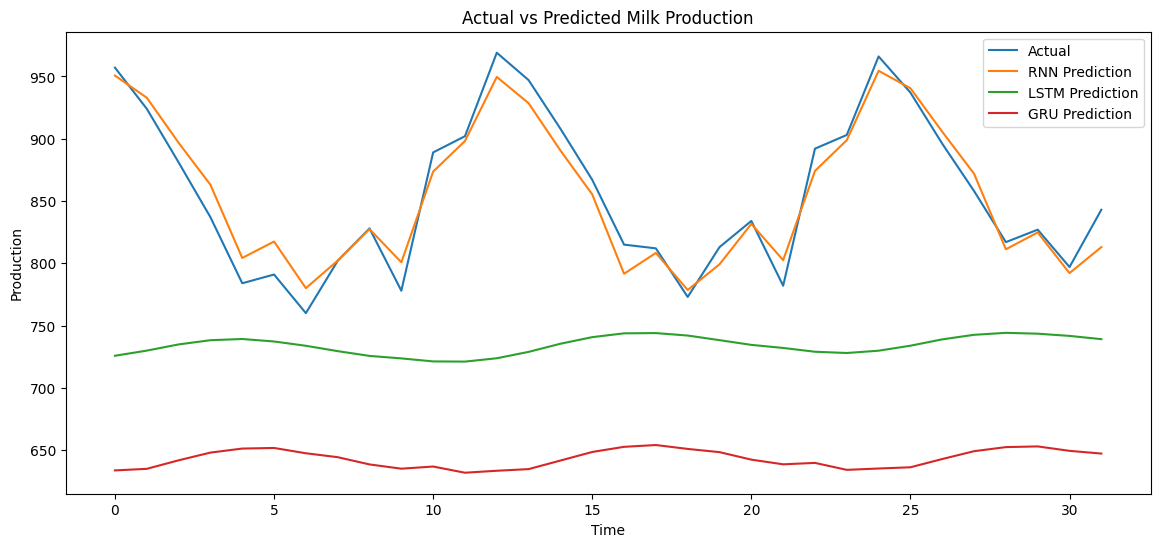

In [14]:
# Step 13: Plot Predictions

plt.figure(figsize=(14,6))

plt.plot(y_test_actual, label="Actual")
plt.plot(rnn_pred, label="RNN Prediction")
plt.plot(lstm_pred, label="LSTM Prediction")
plt.plot(gru_pred, label="GRU Prediction")

plt.title("Actual vs Predicted Milk Production")
plt.xlabel("Time")
plt.ylabel("Production")
plt.legend()
plt.show()

In [20]:
# Step 14: Future Forecast (12 Months)

future_steps = 12

last_sequence = scaled_data[-time_step:]
temp_input = list(last_sequence)
future_predictions = []

for i in range(future_steps):
    x_input = np.array(temp_input[-time_step:])
    x_input = x_input.reshape(1, time_step, 1)

    pred = rnn_model.predict(x_input, verbose=0)
    future_predictions.append(pred[0][0])

    temp_input.append(pred[0])

# Inverse Transform
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

print("\nNext 12 Months Forecast:")
print(future_predictions)




Next 12 Months Forecast:
[[837.2946 ]
 [806.45374]
 [886.8982 ]
 [891.23157]
 [945.475  ]
 [929.6417 ]
 [900.86346]
 [872.479  ]
 [829.18835]
 [839.30237]
 [810.81433]
 [838.3743 ]]


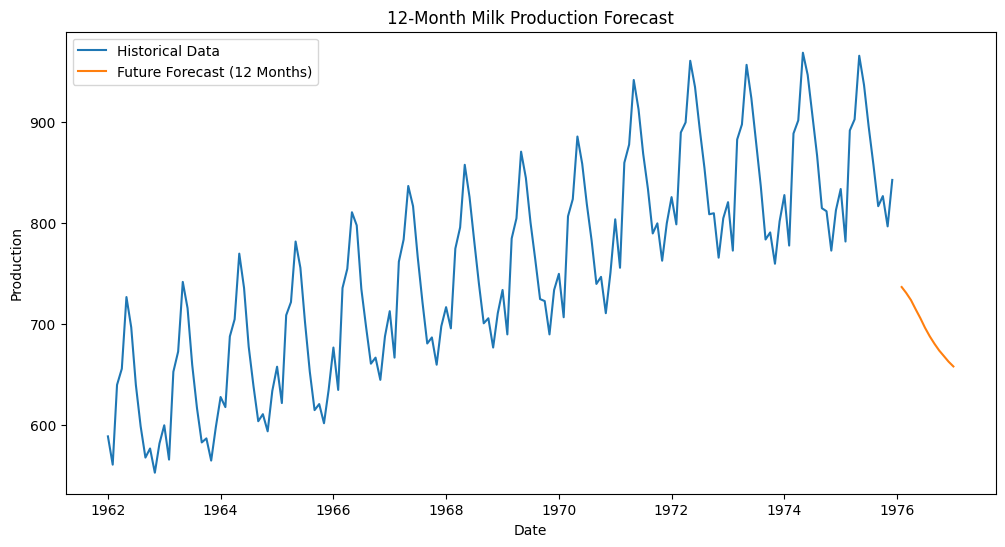

In [16]:
# Step 15: Plot Future Forecast

plt.figure(figsize=(12,6))

plt.plot(df.index, df['Production'], label="Historical Data")

future_dates = pd.date_range(
    start=df.index[-1],
    periods=13,
    freq='M'
)[1:]

plt.plot(
    future_dates,
    future_predictions,
    label="Future Forecast (12 Months)"
)

plt.title("12-Month Milk Production Forecast")
plt.xlabel("Date")
plt.ylabel("Production")
plt.legend()
plt.show()
